In [ ]:
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report, 
    roc_curve, 
    auc
)
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
import optuna
import cupy as cp
from sklearn.metrics import precision_recall_curve

## Funções

In [69]:
def plot_ks_curve(y_true, y_score):
    """
    y_true: valores reais (0 ou 1)
    y_score: probabilidade prevista para a classe positiva
    """

    # Probabilidades de cada classe
    score_0 = np.sort(y_score[y_true == 0])
    score_1 = np.sort(y_score[y_true == 1])

    # Limiar comum
    thresholds = np.sort(np.unique(y_score))

    # ECDF de cada classe
    ecdf_0 = np.searchsorted(score_0, thresholds, side='right') / len(score_0)
    ecdf_1 = np.searchsorted(score_1, thresholds, side='right') / len(score_1)

    # Estatística KS
    diff = np.abs(ecdf_1 - ecdf_0)
    ks = diff.max()
    idx = diff.argmax()
    ks_threshold = thresholds[idx]

    # Plot
    plt.figure(figsize=(8,6))

    plt.plot(
        thresholds,
        ecdf_0,
        label='Classe 0',
        linewidth=2
    )

    plt.plot(
        thresholds,
        ecdf_1,
        label='Classe 1',
        linewidth=2
    )

    # Linha vertical do KS
    plt.vlines(
        ks_threshold,
        ecdf_0[idx],
        ecdf_1[idx],
        colors='black',
        linestyles='dashed',
        linewidth=2,
        label=f'KS = {ks:.3f} em {ks_threshold:.3f}'
    )

    plt.xlabel('Threshold')
    plt.ylabel('Percentual abaixo do threshold')
    plt.title('KS Statistic Plot')

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    return ks

In [ ]:
def evaluate_model(model, X, y, plot=True):

    # Predições
    y_pred = model.predict(X)
    y_score = model.predict_proba(X)[:, 1]

    # Métricas
    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-score": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_score)
    }

    # Curva ROC
    fpr, tpr, _ = roc_curve(y, y_score)

    if plot:
        plt.figure(figsize=(7, 6))

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"AUC = {metrics['ROC-AUC']:.3f}"
        )

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="gray",
            label="Random Classifier"
        )

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)

        plt.show()

    return pd.DataFrame([metrics]).round(2)

## Dados

In [2]:
treino = "./data/train.csv"
teste = "./data/test.csv"
validacao = "./data/validation.csv"

df_treino = pd.read_csv(treino)
df_teste = pd.read_csv(teste)
df_validacao = pd.read_csv(validacao)

X_train = df_treino.drop(columns=['Churn'])
y_train = df_treino['Churn']

X_val = df_validacao.drop(columns=['Churn'])
y_val = df_validacao['Churn']

X_test = df_teste.drop(columns=['Churn'])
y_test = df_teste['Churn']


## Modelo

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    max_leaves=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.1,
    scale_pos_weight=1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
)

In [87]:
X_train_cv = pd.concat([X_train, X_val])
y_train_cv = pd.concat([y_train, y_val])

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10, log=True),
        "reg_lambda": trial.suggest_float( "reg_lambda", 1e-5, 10, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 5),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "device": "cuda",
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = []

    for tr, va in skf.split(X_train_cv, y_train_cv):

        model = XGBClassifier(**params)

        model.fit(
            X_train_cv.iloc[tr],
            y_train_cv.iloc[tr]
        )

        pred = model.predict_proba(
            X_train_cv.iloc[va]
        )[:, 1]

        scores.append(
            roc_auc_score(
                y_train_cv.iloc[va],
                pred
            )
        )

    return np.mean(scores)

study = optuna.create_study(study_name="xgb_gpu", direction="maximize")
study.optimize(objective, n_trials=150, show_progress_bar=True, n_jobs=-1)

best_params = study.best_params

[I 2026-06-28 03:23:47,965] A new study created in memory with name: xgb_gpu
Best trial: 15. Best value: 0.847949:   1%|          | 1/150 [00:24<1:01:46, 24.88s/it]

[I 2026-06-28 03:24:12,834] Trial 15 finished with value: 0.8479488602182368 and parameters: {'n_estimators': 206, 'learning_rate': 0.08435743508472127, 'max_depth': 8, 'subsample': 0.5313499672111333, 'colsample_bytree': 0.661865415469467, 'min_child_weight': 5, 'gamma': 3.7865526375328185, 'reg_alpha': 1.9305352247956908, 'reg_lambda': 0.00041090716304504916, 'scale_pos_weight': 0.9888152428619958}. Best is trial 15 with value: 0.8479488602182368.


Best trial: 15. Best value: 0.847949:   1%|▏         | 2/150 [00:27<29:16, 11.87s/it]  

[I 2026-06-28 03:24:15,603] Trial 7 finished with value: 0.8444676532535601 and parameters: {'n_estimators': 243, 'learning_rate': 0.2276619952290505, 'max_depth': 7, 'subsample': 0.8505781383473254, 'colsample_bytree': 0.5130759774932234, 'min_child_weight': 9, 'gamma': 3.296846627708179, 'reg_alpha': 0.013724494188263507, 'reg_lambda': 0.0008501076607995254, 'scale_pos_weight': 2.18790230845959}. Best is trial 15 with value: 0.8479488602182368.


Best trial: 15. Best value: 0.847949:   2%|▏         | 3/150 [00:29<17:46,  7.26s/it]

...

[I 2026-06-28 03:39:41,972] Trial 148 finished with value: 0.8477286972537084 and parameters: {'n_estimators': 791, 'learning_rate': 0.021485458455998144, 'max_depth': 5, 'subsample': 0.862671508750223, 'colsample_bytree': 0.6390488074463176, 'min_child_weight': 9, 'gamma': 3.4276629642588308, 'reg_alpha': 0.034179873905929525, 'reg_lambda': 0.0015042536837635895, 'scale_pos_weight': 0.9651891162919619}. Best is trial 136 with value: 0.8488307914878949.


Best trial: 136. Best value: 0.848831:  99%|█████████▉| 149/150 [15:54<00:01,  1.88s/it]

[I 2026-06-28 03:39:42,878] Trial 149 finished with value: 0.8478595339987152 and parameters: {'n_estimators': 790, 'learning_rate': 0.02115778954176422, 'max_depth': 5, 'subsample': 0.8639434846096041, 'colsample_bytree': 0.639400061800925, 'min_child_weight': 6, 'gamma': 3.4443443647734533, 'reg_alpha': 0.04485254075071142, 'reg_lambda': 0.05220321727112904, 'scale_pos_weight': 0.8188743592122227}. Best is trial 136 with value: 0.8488307914878949.


Best trial: 136. Best value: 0.848831: 100%|██████████| 150/150 [15:56<00:00,  6.37s/it]

[I 2026-06-28 03:39:44,068] Trial 147 finished with value: 0.8479294937065707 and parameters: {'n_estimators': 792, 'learning_rate': 0.015487505864238948, 'max_depth': 5, 'subsample': 0.8657018449730118, 'colsample_bytree': 0.6462506428420074, 'min_child_weight': 9, 'gamma': 3.4220943372419663, 'reg_alpha': 0.0017970545490544664, 'reg_lambda': 0.02780393557426596, 'scale_pos_weight': 0.9363731054783301}. Best is trial 136 with value: 0.8488307914878949.


In [90]:
print(f'Best parameters: {best_params}')

Best parameters: {'n_estimators': 790, 'learning_rate': 0.018622640546256706, 'max_depth': 3, 'subsample': 0.7797652852908156, 'colsample_bytree': 0.6927078564761739, 'min_child_weight': 9, 'gamma': 3.512447090871432, 'reg_alpha': 0.0024706228891333546, 'reg_lambda': 0.0024329820949518296, 'scale_pos_weight': 0.9918633379532811}


In [97]:
model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

In [100]:
probs = model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, probs)

f1 = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_threshold = thresholds[np.argmax(f1)]

print(best_threshold)

preds = (probs >= best_threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_val, preds),
    "Precision": precision_score(y_val, preds),
    "Recall": recall_score(y_val, preds),
    "F1-score": f1_score(y_val, preds),
    "ROC-AUC": roc_auc_score(y_val, probs)
}

metrics_df = pd.DataFrame([metrics]).round(2)
metrics_df


0.37597176


,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.79,0.59,0.72,0.65,0.85


In [92]:
metrics_train = evaluate_model(model, X_train, y_train, plot=False)
metrics_train.index = ['Train']
metrics_val = evaluate_model(model, X_val, y_val, plot=False)
metrics_val.index = ['Validation']
metrics = pd.concat([metrics_train, metrics_val])
metrics

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Train,0.82,0.70,0.53,0.61,0.86
Validation,0.80,0.66,0.52,0.58,0.85


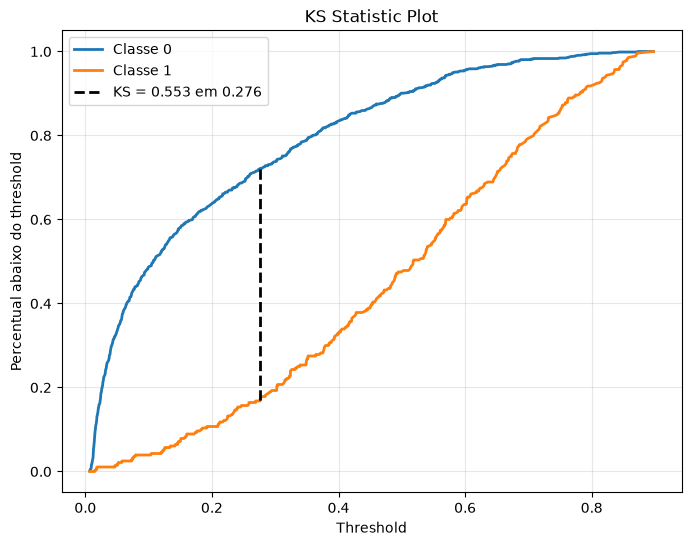

np.float64(0.5525036818851252)

In [93]:
plot_ks_curve(y_val, model.predict_proba(X_val)[:, 1])

### Teste

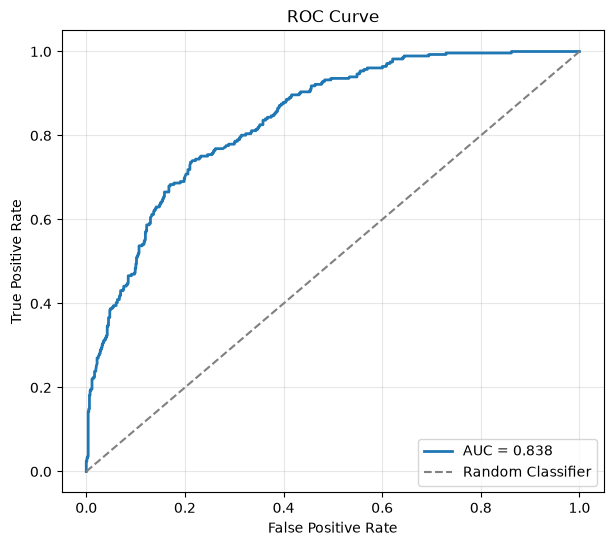

,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.79,0.66,0.46,0.54,0.84


In [94]:
metrics = evaluate_model(model, X_test, y_test, plot=True)
metrics

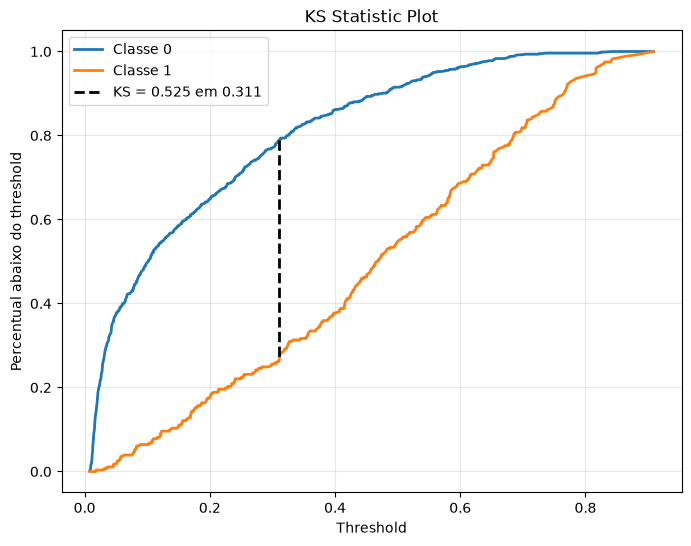

np.float64(0.5253145980848957)

In [95]:
plot_ks_curve(y_test, model.predict_proba(X_test)[:, 1])